# Piecewise landscape

This “survival over price bins” view is standard for censored winning-price estimation in RTB, and more flexible than assuming a single lognormal form. Prior work on RTB winning-price prediction explicitly uses censored regression / survival ideas because losing auctions only reveal that the clearing price exceeded your bid, not the exact price. More recent work also argues that fixed parametric assumptions like Gaussian/lognormal/gamma can be too restrictive and proposes more flexible distribution modeling under censorship.

In [12]:
import sys
sys.path.append("..")
import numpy as np
from src.piecewise_landscape import make_log_price_bins, simulate_censored_auctions, sample_piecewise_market, sample_bids_from_value_model, PiecewiseSurvivalLandscape
import src.plots as plots

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Example usage

In [7]:
rng = np.random.default_rng(7)

# 1) Define price bins
bin_edges = make_log_price_bins(p_min=0.01, p_max=20.0, n_bins=30)

# 2) Create synthetic market
market = sample_piecewise_market(
    n_segments=8,
    bin_edges=bin_edges,
    n_auctions=50000,
    random_state=7,
)

# 3) Simulate bids
base_value_by_segment = np.exp(rng.normal(np.log(1.2), 0.5, size=8))
bids = sample_bids_from_value_model(
    segment_id=market.segment_id,
    base_value_by_segment=base_value_by_segment,
    noise_scale=0.65,
    random_state=11,
)

# 4) Convert to censored auction logs
data = simulate_censored_auctions(market, bids)

# 5) Fit landscape estimator
model = PiecewiseSurvivalLandscape(
    bin_edges=bin_edges,
    n_segments=8,
    l2_alpha=1e-4,
    l2_u=5e-4,
    random_state=3,
)
model.fit(data, lr=0.08, n_epochs=250, verbose=True)

# 6) Compare recovered CDF on one segment
for seg in range(8):
    summary = model.true_vs_estimated_summary(market.cdf_true, segment_id=seg)
    mae = summary["abs_err"].mean()
    print(f"\nsegment={seg}  CDF bin-wise MAE={mae:.4f}")

# 7) Query p_win / expected_spend
test_bids = np.array([0.05, 0.10, 0.25, 0.50, 1.0, 2.0, 5.0])
pwin = model.p_win(test_bids, segment_id=seg)
esp = model.expected_spend(test_bids, segment_id=seg)

print("\nSample landscape:")
for b, pw, es in zip(test_bids, pwin, esp):
    print(f"bid={b:>5.2f}  p_win={pw:>7.4f}  expected_spend={es:>7.4f}")

epoch=   1  loss=5.200460
epoch=  25  loss=4.154150
epoch=  50  loss=3.632945
epoch=  75  loss=3.353416
epoch= 100  loss=3.187709
epoch= 125  loss=3.082142
epoch= 150  loss=3.011175
epoch= 175  loss=2.961422
epoch= 200  loss=2.925331
epoch= 225  loss=2.898388
epoch= 250  loss=2.877770

segment=0  CDF bin-wise MAE=0.0393

segment=1  CDF bin-wise MAE=0.0109

segment=2  CDF bin-wise MAE=0.0581

segment=3  CDF bin-wise MAE=0.1200

segment=4  CDF bin-wise MAE=0.0710

segment=5  CDF bin-wise MAE=0.1256

segment=6  CDF bin-wise MAE=0.0209

segment=7  CDF bin-wise MAE=0.0379

Sample landscape:
bid= 0.05  p_win= 0.6539  expected_spend= 0.0154
bid= 0.10  p_win= 0.8251  expected_spend= 0.0273
bid= 0.25  p_win= 0.9449  expected_spend= 0.0459
bid= 0.50  p_win= 0.9827  expected_spend= 0.0587
bid= 1.00  p_win= 0.9961  expected_spend= 0.0676
bid= 2.00  p_win= 0.9994  expected_spend= 0.0718
bid= 5.00  p_win= 0.9999  expected_spend= 0.0735


# Plots|

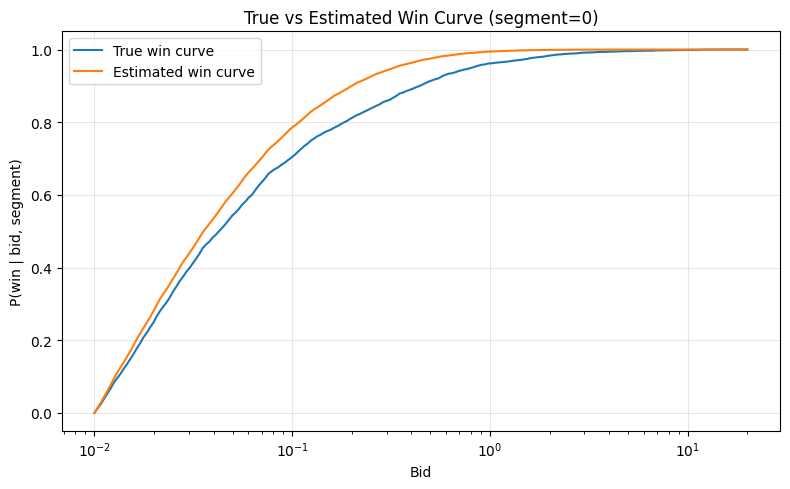

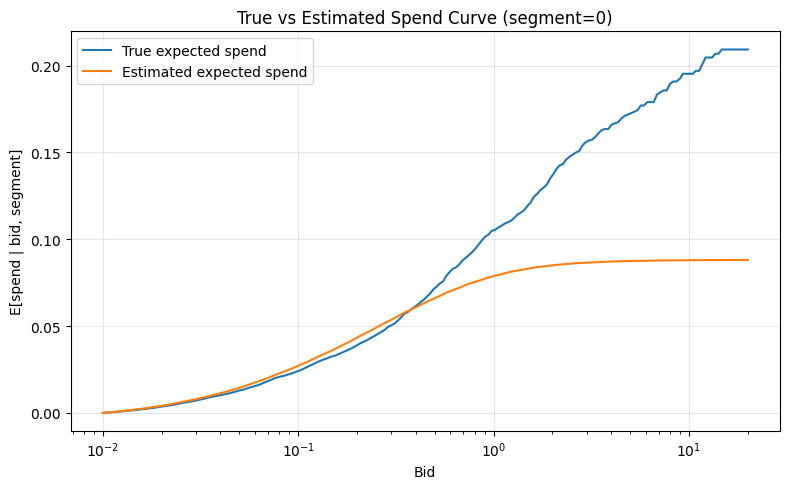

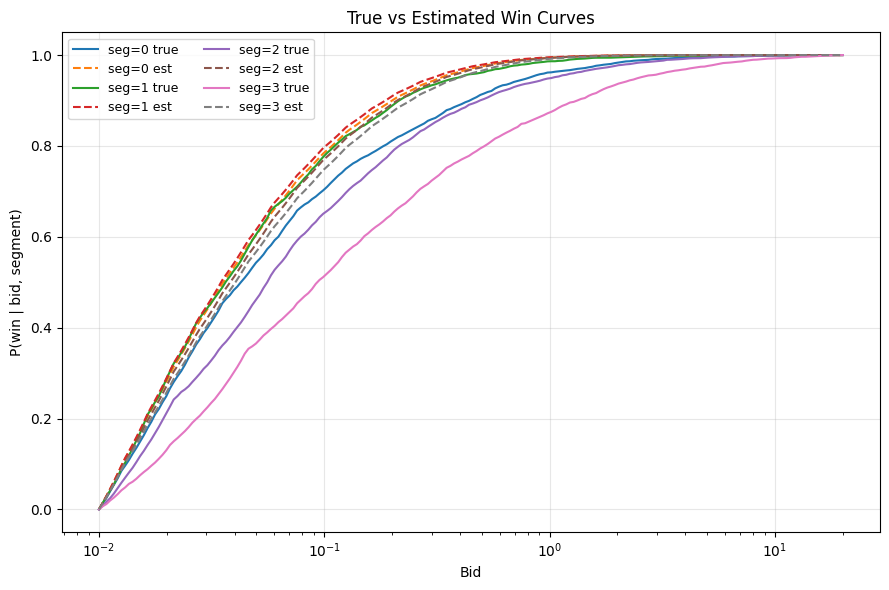

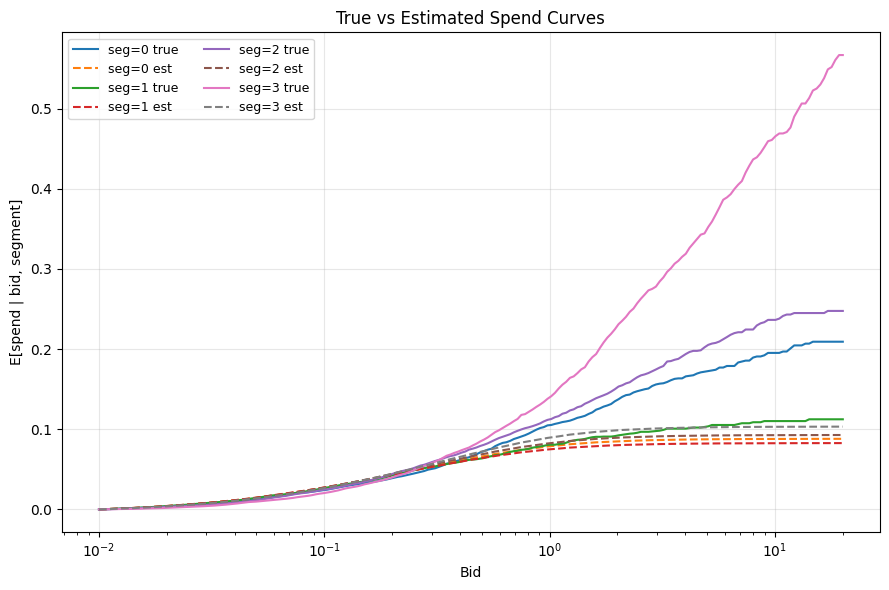

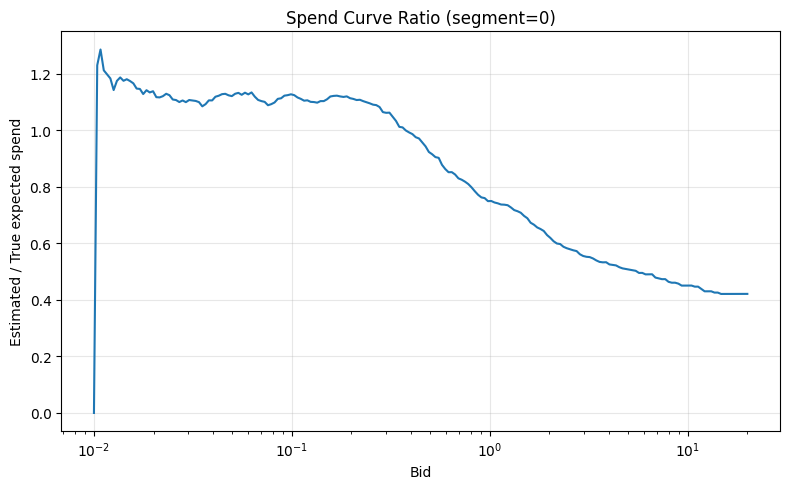

In [14]:
# Single segment diagnostic
plots.plot_true_vs_estimated_curves(model, market, segment_id=0)

# Multi-segment overlay
plots.plot_multiple_segments(model, market, segments=[0, 1, 2, 3])

# Estimated spend error ratio.
plots.plot_spend_ratio(model, market, segment_id=0)
